In [1]:
import os
from typing import Literal, Tuple, Optional
import logging
import math

from catboost import CatBoostRegressor
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pycatch22 import catch22_all
from scipy.interpolate import PchipInterpolator
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

from forecasting_module import TimeGPTForecaster, SARIMAXForecaster
from utils import ForecastUtils

from lstm_network import LSTMModel, LSTMTrainer

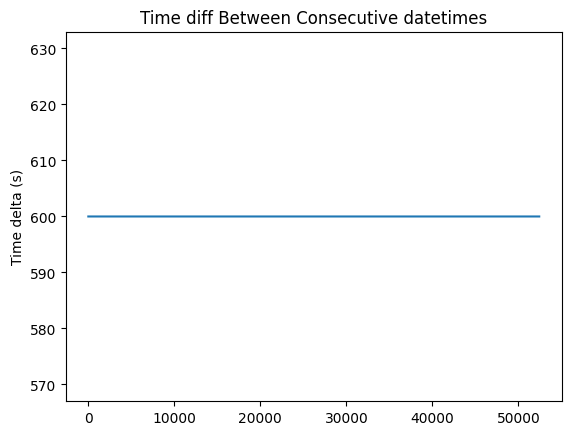

In [2]:
def plot_time_deltas(df: pd.DataFrame, time_col: str) -> None:
    """Calculate time diff between consecutive datetime entries in the specified column,
    and plot these time deltas"""
    df[time_col]= pd.to_datetime(df[time_col])
    diffs       = df[time_col].diff().dropna()
    plt.plot(diffs.dt.total_seconds())
    plt.ylabel('Time delta (s)')
    plt.title('Time diff Between Consecutive datetimes')
    plt.show()

datasets = {"GDELT_USA_LAB":      {"path": "Time-IMM/GDELT_USA_LAB",       "time_col": "date_time", "y": ["AvgTone"]},
            # "ClusterTrace_707":   {"path": "Time-IMM/ClusterTrace_707",    "time_col": "date_time", "y": ["cpu", "memory"]},
            "EPA_air_los_angeles":{"path": "Time-IMM/EPA_air_los_angeles", "time_col": "date_time", "y": ["ozone"]},
            "FNSPID_EXPE":        {"path": "Time-IMM/FNSPID_EXPE",         "time_col": "date_time", "y": ["adj close"]},
            # "ILINet":             {"path": "Time-IMM/ILINet",              "time_col": "date_time", "y": ["TOTAL PATIENTS"]},
            "repohealth_facebook":{"path": "Time-IMM/repohealth_facebook", "time_col": "date_time", "y": ["new_issues"]},
            "studentlife_fc7337": {"path": "Time-IMM/studentlife_fc7337",  "time_col": "date_time", "y": ["sleep_duration"]},
            "power_consumption":  {"path": "power_consumption",            "time_col": "Datetime",  "y": ["PowerConsumption_Zone1", "PowerConsumption_Zone2", "PowerConsumption_Zone3"]},
            "appliances_energy":  {"path": "appliances_energy",            "time_col": "date",      "y": ["rv1", "rv2"]}}

desired_dataset= "power_consumption"

df             = pd.read_csv(f"../public_datasets/{datasets[desired_dataset]['path']}.csv")
time_col_name  = datasets[desired_dataset]["time_col"]

"""Pre-processing each dataset"""
try:
    if desired_dataset == "GDELT_USA_LAB":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ClusterTrace_707":
        pass
    elif desired_dataset == "EPA_air_los_angeles":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "FNSPID_EXPE":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "ILINet":
        df.drop(["record_id"], axis=1, inplace=True)
        df = df.drop_duplicates(subset=['date_time'], keep='first').reset_index(drop=True) #some rows have same time
    elif desired_dataset == "repohealth_facebook":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "studentlife_fc7337":
        df.drop(["record_id"], axis=1, inplace=True)
    elif desired_dataset == "power_consumption":
        df.drop(["PowerConsumption_Zone2", "PowerConsumption_Zone3"], axis=1, inplace=True)
    elif desired_dataset == "appliances_energy":
        df.drop(["rv2"], axis=1, inplace=True)
except Exception as e:
    pass

y_cols = [col for col in datasets[desired_dataset]["y"] if col in df.columns]
df = df.fillna(0)

plot_time_deltas(df, time_col_name)


In [3]:
"""Common pre-processing steps"""

# interpolate irregular timestamps first
time_delta = df[time_col_name].diff().dropna()
if time_delta.nunique() == 1: # timestamps uniform, skip PCHIP
    df_uniform = df.copy()
else:
    freq       = ForecastUtils.infer_dominant_freq(df, time_col_name)
    df_uniform = ForecastUtils.apply_pchip_interpolation(df, time_col_name, freq)

horizon  = ForecastUtils.compute_horizon(len(df_uniform), fixed_points=20, pct=0.01)
n_train  = len(df_uniform) - horizon
df_train = df_uniform.iloc[:n_train].copy()
df_test  = df_uniform.iloc[n_train:].copy()

n_windows     = 5    # windows to create 
horizon       = 10   # prediction horizon for each window
horizon_frac  = 0.01 # frac of ENTIRE series length
min_window_len= 1008 # len of smallest window (1008 is timeGPT default)


Horizon = 525 steps (fixed_points=20, pct=0.01)


In [ ]:
"""TimeGPT"""
NIXTLA_API_KEY = 'nixak-TnuMDCHsSM4hajkuXycqZZrNxwtAIoT9O9H7Q8ZwKl2JuJlazRqIPknwJW1AVHX2yB3yfCAwmAogugqQ'
logging.getLogger("nixtla").setLevel(logging.WARNING)

forecaster = TimeGPTForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols, api_key=NIXTLA_API_KEY)

"""single window evaluation"""
print("==== single window evaluation ====")
forecast_dict, _ = forecaster.forecast_timegpt(df_train, df_test, horizon, use_exogenous_cols=True)
forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

"""Multi-window evaluation"""
print("==== multi window evaluation ====")
use_exogenous_cols=True
windows_list  = ForecastUtils.make_windows(df_uniform, n_windows=n_windows, horizon_len=horizon, 
                                           horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)
all_forecasts, mae_list, sizes = {}, [], []

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train shape {train_df.shape}, test shape {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_timegpt(train_df, test_df, horizon_len=horizon, use_exogenous_cols=use_exogenous_cols)
    all_forecasts[f"window_{i}"] = forecast_dict

    # Compute MAE per window
    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j] # shape = H
        y_pred = forecast_dict[target]
        mae    = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# Step 3: compute weighted MAE across windows (horizon = weight)
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")

# # Plot:
# client.plot(df, forecast_df, time_col=time_col_name, target_col=y_cols[0], level=[80,90])

# show last 2% of the history + all predictions
# n = int(len(df) * 0.02)
# df_tail = df.tail(n)
# forecast_tail = forecast_df[forecast_df[time_col_name] >= df_tail[time_col_name].iloc[0]]
# client.plot(df_tail,forecast_tail,time_col=time_col_name,target_col=y_cols[0],level=[80, 90])


In [ ]:
"""SARIMAX"""
logging.basicConfig(level=logging.INFO)

forecaster = SARIMAXForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols)

print("==== single window evaluation ====")
forecast_dict, y_true_scaled = forecaster.forecast_sarimax(df_train, df_test, horizon, 
                                                           order=(1, 0, 0), seasonal_order=(0, 0, 0, 0))
forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

print("==== multi window evaluation ====")
use_exogenous_cols = False
windows_list = ForecastUtils.make_windows(df_uniform, n_windows=n_windows, horizon_len=horizon, 
                                          horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)
all_forecasts, mae_list, sizes = {}, [], []

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train shape {train_df.shape}, test shape {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_sarimax(train_df, test_df, horizon, order=(1, 0, 0),
                                                               seasonal_order=(0, 0, 0, 0), use_exogenous_cols=use_exogenous_cols)
    all_forecasts[f"window_{i}"] = forecast_dict

    # Compute MAE per window
    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j]
        y_pred = forecast_dict[target]
        mae    = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# ---- Weighted MAE ----
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")


In [ ]:
"""run AE"""
import autoencoder as ae
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, TensorDataset
from utils import Losses

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Example params ===
input_rows        = 1000
input_cols        = 20
layer1_dim        = 64
layer2_dim        = 32
latent_dim        = 8
dropout_prob      = 0.1
layer_dims        = [input_cols, 64, 32, latent_dim]  # for FlexibleAE
pred_dim          = 0
projection_dim    = 0
batch_size        = 32
epochs            = 100
lr                = 1e-3
weight_decay      = 1e-5
scheduler_patience= 5
# === Dummy dataset ===
x_train      = torch.randn(input_rows, input_cols)
train_loader = DataLoader(list(zip(x_train, x_train)), batch_size=batch_size, shuffle=True)

# === Initialize AE ===
simple_ae   = ae.SimpleAutoencoder(input_cols, layer1_dim, layer2_dim, latent_dim, dropout_prob).to(device)
flexible_ae = ae.FlexibleAutoencoder(layer_dims, pred_dim, dropout_prob, projection_dim, pred_hidden_dim=32, mode="reconstruct").to(device)

# === Optimizer & scheduler ===
optimizer = torch.optim.AdamW(simple_ae.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)

# === Trainer ===
trainer   = ae.TrainAutoencoder()
best_loss = trainer.train_autoencoder(device, simple_ae, epochs, train_loader, optimizer, scheduler)
print("Best training loss (SimpleAE):", best_loss)

# === FlexibleAE example ===
optimizer = torch.optim.AdamW(flexible_ae.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience)
best_loss = trainer.train_autoencoder(device, flexible_ae, epochs, train_loader, optimizer, scheduler)
print("Best training loss (FlexibleAE):", best_loss)


Epoch [20/100], training loss: 0.7273
Epoch [40/100], training loss: 0.7029
Epoch [60/100], training loss: 0.6855
Epoch [80/100], training loss: 0.6827
Epoch [100/100], training loss: 0.6780
Best training loss (SimpleAE): 0.6780446674674749
Epoch [20/100], training loss: 0.8535
Epoch [40/100], training loss: 0.8052
Epoch [60/100], training loss: 0.7774
Epoch [80/100], training loss: 0.7691
Epoch [100/100], training loss: 0.7633
Best training loss (FlexibleAE): 0.7572619374841452


In [ ]:
"""Multistep LSTM predictor"""
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import torch.optim as optim
from forecasting_module import BaseForecaster

class FlexibleLSTM(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, output_dim: int):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])  # last step only

class FlexibleLSTMTrainer:
    def __init__(self, model, lr=1e-3, epochs=30, device="cpu"):
        self.model = model.to(device)
        self.lr = lr
        self.epochs = epochs
        self.device = device
        self.loss_fn = nn.MSELoss()

    def _make_batches(self, y, X, seq_len, horizon):
        """Convert timeseries to (X_seq, y_future) windows."""
        data = y if X is None else np.concatenate([y, X], axis=1)
        X_batches, y_batches = [], []
        for i in range(len(data) - seq_len - horizon):
            X_batches.append(data[i:i+seq_len])
            y_batches.append(y[i+seq_len:i+seq_len+horizon])
        return (torch.tensor(np.stack(X_batches), dtype=torch.float32),
                torch.tensor(np.stack(y_batches), dtype=torch.float32),)

    def fit(self, y_train, X_train, seq_len, horizon, y_val=None, X_val=None):
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        Xb, yb = self._make_batches(y_train, X_train, seq_len, horizon)
        Xb, yb = Xb.to(self.device), yb.to(self.device)

        for epoch in range(self.epochs):
            self.model.train()
            optimizer.zero_grad()
            preds = self.model(Xb)
            loss  = self.loss_fn(preds, yb[:, -1, :])  # predict horizon last-step
            loss.backward()
            optimizer.step()
            if (epoch+1) % 10 == 0:
                print(f"Epoch {epoch+1}, loss={loss.item():.4f}")

    def predict_seq2seq(self, y_test, X_test, seq_len, horizon):
        Xb, yb = self._make_batches(y_test, X_test, seq_len, horizon)
        self.model.eval()
        with torch.no_grad():
            preds = self.model(Xb.to(self.device)).cpu().numpy()
        return preds

    def predict_autoreg(self, y_test, X_test, seq_len, horizon):
        """Step-by-step forecasting with feedback of predictions."""
        data  = y_test if X_test is None else np.concatenate([y_test, X_test], axis=1)
        preds = []
        self.model.eval()
        with torch.no_grad():
            for i in range(len(data) - seq_len - horizon):
                window = torch.tensor(data[i:i+seq_len], dtype=torch.float32).unsqueeze(0).to(self.device)
                pred   = self.model(window).cpu().numpy()
                preds.append(pred)
                # feed prediction back only into y part (not exogenous)
                data[i+seq_len] = np.concatenate([pred[0], data[i+seq_len, y_test.shape[1]:]])
        return np.array(preds)


class LSTMForecaster(BaseForecaster):
    def __init__(self, df, time_col: str, y_cols: list[str],
                 use_exogenous: bool = False, seq_len: int = 30, horizon: int = 10,
                 hidden_size: int = 64, epochs: int = 30, lr: float = 1e-3):
        super().__init__(df, time_col, y_cols)
        self.use_exogenous = use_exogenous
        self.seq_len = seq_len
        self.horizon = horizon
        self.hidden_size = hidden_size
        self.epochs = epochs
        self.lr = lr

        # Exogenous columns = all columns minus time + y
        if self.use_exogenous:
            self.X_cols = [c for c in df.columns if c not in [time_col] + y_cols]
        else:
            self.X_cols = []

    def _prepare_data(self, df):
        """Return tensors for y (and X if exogenous)."""
        y = df[self.y_cols].values.astype(np.float32)
        if self.use_exogenous and self.X_cols:
            X = df[self.X_cols].values.astype(np.float32)
        else:
            X = None
        return y, X

    def fit(self, df_train, df_val=None):
        y_train, X_train = self._prepare_data(df_train)
        y_val, X_val = (None, None) if df_val is None else self._prepare_data(df_val)

        self.model = FlexibleLSTM(
            input_dim=len(self.y_cols) + (X_train.shape[1] if X_train is not None else 0),
            hidden_size=self.hidden_size,
            output_dim=len(self.y_cols))

        trainer = FlexibleLSTMTrainer(self.model, lr=self.lr, epochs=self.epochs)
        trainer.fit(y_train, X_train, self.seq_len, self.horizon,
                    y_val=y_val, X_val=X_val)
        self.trainer = trainer

    def predict(self, df_test, autoregressive: bool = False):
        y_test, X_test = self._prepare_data(df_test)
        if autoregressive:
            return self.trainer.predict_autoreg(y_test, X_test, self.seq_len, self.horizon)
        else:
            return self.trainer.predict_seq2seq(y_test, X_test, self.seq_len, self.horizon)

    def forecast_lstm(self, train_df, test_df, horizon: int,
                      use_exogenous: bool = True, stepwise: bool = False):
        """Train + forecast like SARIMAX.
        Args:
            train_df, test_df: pandas DataFrames
            horizon: forecast horizon
            use_exogenous: toggle exogenous features
            stepwise: if True → autoregressive, else → direct multi-step
        Returns:
            forecast_dict: {y_col: np.array predictions}
            y_true: true target values (scaled)"""
        # override exogenous toggle for this run
        self.use_exogenous = use_exogenous
        if use_exogenous:
            self.X_cols = [c for c in train_df.columns if c not in [self.time_col] + self.y_cols]
        else:
            self.X_cols = []

        self.fit(train_df)
        preds = self.predict(test_df, autoregressive=stepwise)
        y_true, _ = self._prepare_data(test_df)

        if preds.ndim == 1:
            preds = preds.reshape(-1, 1)

        forecast_dict = {col: preds[:, i] for i, col in enumerate(self.y_cols)}
        self.forecast_dfs = {col: forecast_dict[col] for col in self.y_cols}
        return forecast_dict, y_true


"""LSTM run"""
n_windows = 5
horizon = 10       # prediction steps
seq_len = 30       # past steps
# min_window_len = seq_len + horizon  # ensure each window is long enough

logging.basicConfig(level=logging.INFO)

forecaster = LSTMForecaster(df_uniform, time_col=time_col_name, y_cols=y_cols, seq_len=seq_len)

print("==== single window evaluation ====")
# forecast_dict, y_true_scaled = forecaster.forecast_lstm(
#     df_train, df_test, horizon,
#     use_exogenous=True,   # or False
#     stepwise=False)        # sequence prediction (False) or step-by-step (True)

# forecast_df_temp = forecaster.forecast_dfs[y_cols[0]]

print("==== multi window evaluation ====")
all_forecasts, mae_list, sizes = {}, [], []
windows_list = ForecastUtils.make_windows(
    df_uniform, n_windows=n_windows, horizon_len=horizon,
    horizon_frac=horizon_frac, min_window_len=min_window_len, start_point=0)

for i, (train_df, test_df) in enumerate(windows_list):
    print(f"Window {i}: train {train_df.shape}, test {test_df.shape}")
    forecast_dict, y_true_scaled = forecaster.forecast_lstm(
        train_df, test_df, horizon,
        use_exogenous=True,
        stepwise=True)
    all_forecasts[f"window_{i}"] = forecast_dict

    for j, target in enumerate(y_cols):
        y_true = y_true_scaled[:, j]
        y_pred = forecast_dict[target]
        mae = mean_absolute_error(y_true, y_pred)
        mae_list.append(mae)
        sizes.append(len(y_true))

# ---- Weighted MAE ----
weighted_mae = sum(MAE * n for MAE, n in zip(mae_list, sizes)) / sum(sizes)
std_mae      = math.sqrt(sum((MAE - weighted_mae) ** 2 * n for MAE, n in zip(mae_list, sizes)) / sum(sizes))
print(f"Final MAE: mean ± std= {{{weighted_mae:.4f}}}{{{std_mae:.4f}}}")


In [ ]:
"""Conditional VAE (https://github.com/unnir/cVAE/blob/master/cvae.py)"""
import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image

# cuda setup
device = torch.device("cuda")
kwargs = {'num_workers': 1, 'pin_memory': True} 

# hyper params
batch_size = 64
latent_size = 20
epochs = 10


train_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=True, **kwargs)

test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, transform=transforms.ToTensor()),
    batch_size=batch_size, shuffle=False, **kwargs)


def one_hot(labels, class_size):
    targets = torch.zeros(labels.size(0), class_size)
    for i, label in enumerate(labels):
        targets[i, label] = 1
    return targets.to(device)


class CVAE(nn.Module):
    def __init__(self, feature_size, latent_size, class_size):
        super(CVAE, self).__init__()
        self.feature_size = feature_size
        self.class_size = class_size

        # encode
        self.fc1  = nn.Linear(feature_size + class_size, 400)
        self.fc21 = nn.Linear(400, latent_size)
        self.fc22 = nn.Linear(400, latent_size)

        # decode
        self.fc3 = nn.Linear(latent_size + class_size, 400)
        self.fc4 = nn.Linear(400, feature_size)

        self.elu = nn.ELU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x, c): # Q(z|x, c)
        '''
        x: (bs, feature_size)
        c: (bs, class_size)
        '''
        inputs = torch.cat([x, c], 1) # (bs, feature_size+class_size)
        h1 = self.elu(self.fc1(inputs))
        z_mu = self.fc21(h1)
        z_var = self.fc22(h1)
        return z_mu, z_var

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z, c): # P(x|z, c)
        '''
        z: (bs, latent_size)
        c: (bs, class_size)
        '''
        inputs = torch.cat([z, c], 1) # (bs, latent_size+class_size)
        h3 = self.elu(self.fc3(inputs))
        return self.sigmoid(self.fc4(h3))

    def forward(self, x, c):
        mu, logvar = self.encode(x.view(-1, 28*28), c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

# create a CVAE model
model = CVAE(28*28, latent_size, 10).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Reconstruction + KL divergence losses summed over all elements and batch
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # see Appendix B from VAE paper:
    # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
    # https://arxiv.org/abs/1312.6114
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)
        labels = one_hot(labels, 10)
        recon_batch, mu, logvar = model(data, labels)
        optimizer.zero_grad()
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.detach().cpu().numpy()
        optimizer.step()
        if batch_idx % 20 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(data)))

    print('====> Epoch: {} Average loss: {:.4f}'.format(
          epoch, train_loss / len(train_loader.dataset)))


def test(epoch):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for i, (data, labels) in enumerate(test_loader):
            data, labels = data.to(device), labels.to(device)
            labels = one_hot(labels, 10)
            recon_batch, mu, logvar = model(data, labels)
            test_loss += loss_function(recon_batch, data, mu, logvar).detach().cpu().numpy()
            if i == 0:
                n = min(data.size(0), 5)
                comparison = torch.cat([data[:n],
                                      recon_batch.view(-1, 1, 28, 28)[:n]])
                save_image(comparison.cpu(),
                         'reconstruction_' + str(f"{epoch:02}") + '.png', nrow=n)

    test_loss /= len(test_loader.dataset)
    print('====> Test set loss: {:.4f}'.format(test_loss))


for epoch in range(1, epochs + 1):
        train(epoch)
        test(epoch)
        with torch.no_grad():
            c = torch.eye(10, 10).cuda()
            sample = torch.randn(10, latent_size).to(device)
            sample = model.decode(sample, c).cpu()
            save_image(sample.view(10, 1, 28, 28),
                       'sample_' + str(f"{epoch:02}") + '.png')


In [ ]:
"""CVAE (https://freedium.cfd/https://medium.com/@sofeikov/implementing-conditional-variational-auto-encoders-cvae-from-scratch-29fcbb8cb08f)"""

import torch.nn as nn

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Set the number of hidden units
        self.num_hidden = 8
        
        # Define the encoder part of the autoencoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),  # input size: 784, output size: 256
            nn.ReLU(),  # apply the ReLU activation function
            nn.Linear(256, self.num_hidden),  # input size: 256, output size: num_hidden
            nn.ReLU(),  # apply the ReLU activation function
        )
        
        # Define the decoder part of the autoencoder
        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, 256),  # input size: num_hidden, output size: 256
            nn.ReLU(),  # apply the ReLU activation function
            nn.Linear(256, 784),  # input size: 256, output size: 784
            nn.Sigmoid(),  # apply the sigmoid activation function to compress the output to a range of (0, 1)
        )

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Pass the encoded representation through the decoder
        decoded = self.decoder(encoded)
        # Return both the encoded representation and the reconstructed output
        return encoded, decoded

class VAE(AutoEncoder):
    def __init__(self):
        super().__init__()
        # Add mu and log_var layers for reparameterization
        self.mu = nn.Linear(self.num_hidden, self.num_hidden)
        self.log_var = nn.Linear(self.num_hidden, self.num_hidden)

    def reparameterize(self, mu, log_var):
        # Compute the standard deviation from the log variance
        std = torch.exp(0.5 * log_var)
        # Generate random noise using the same shape as std
        eps = torch.randn_like(std)
        # Return the reparameterized sample
        return mu + eps * std

    def forward(self, x):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Compute the mean and log variance vectors
        mu = self.mu(encoded)
        log_var = self.log_var(encoded)
        # Reparameterize the latent variable
        z = self.reparameterize(mu, log_var)
        # Pass the latent variable through the decoder
        decoded = self.decoder(z)
        # Return the encoded output, decoded output, mean, and log variance
        return encoded, decoded, mu, log_var

    def sample(self, num_samples):
        with torch.no_grad():
            # Generate random noise
            z = torch.randn(num_samples, self.num_hidden).to(device)
            # Pass the noise through the decoder to generate samples
            samples = self.decoder(z)
        # Return the generated samples
        return samples

class ConditionalVAE(VAE):
    # VAE implementation from the article linked above
    def __init__(self, num_classes):
        super().__init__()
        # Add a linear layer for the class label
        self.label_projector = nn.Sequential(
            nn.Linear(num_classes, self.num_hidden),
            nn.ReLU(),
        )

    def condition_on_label(self, z, y):
        projected_label = self.label_projector(y.float())
        return z + projected_label

    def forward(self, x, y):
        # Pass the input through the encoder
        encoded = self.encoder(x)
        # Compute the mean and log variance vectors
        mu = self.mu(encoded)
        log_var = self.log_var(encoded)
        # Reparameterize the latent variable
        z = self.reparameterize(mu, log_var)
        # Pass the latent variable through the decoder
        decoded = self.decoder(self.condition_on_label(z, y))
        # Return the encoded output, decoded output, mean, and log variance
        return encoded, decoded, mu, log_var

    def sample(self, num_samples, y):
        with torch.no_grad():
            # Generate random noise
            z = torch.randn(num_samples, self.num_hidden).to(device)
            # Pass the noise through the decoder to generate samples
            samples = self.decoder(self.condition_on_label(z, y))
        # Return the generated samples
        return samples

def train_vae(X_train, learning_rate=1e-3, num_epochs=10, batch_size=32):
    # Convert the training data to PyTorch tensors
    X_train = torch.from_numpy(X_train).to(device)

    # Create the autoencoder model and optimizer
    model = VAE()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Define the loss function
    criterion = nn.MSELoss(reduction="sum")

    # Set the device to GPU if available, otherwise use CPU
    model.to(device)

    # Create a DataLoader to handle batching of the training data
    train_loader = torch.utils.data.DataLoader(
        X_train, batch_size=batch_size, shuffle=True
    )

    # Training loop
    for epoch in range(num_epochs):
        total_loss = 0.0
        for batch_idx, data in enumerate(train_loader):
            # Get a batch of training data and move it to the device
            data = data.to(device)

            # Forward pass
            encoded, decoded, mu, log_var = model(data)

            # Compute the loss and perform backpropagation
            KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = criterion(decoded, data) + 3 * KLD
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Update the running loss
            total_loss += loss.item() * data.size(0)

        # Print the epoch loss
        epoch_loss = total_loss / len(train_loader.dataset)
        print(
            "Epoch {}/{}: loss={:.4f}".format(epoch + 1, num_epochs, epoch_loss)
        )

    # Return the trained model
    return model

def loss_function(recon_x, x, mu, logvar):
    # Compute the binary cross-entropy loss between the reconstructed output and the input data
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction="sum")
    # Compute the Kullback-Leibler divergence between the learned latent variable distribution and a standard Gaussian distribution
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    # Combine the two losses by adding them together and return the result
    return BCE + KLD


In [ ]:
"""TimesFM"""
from timesfm import TimesFmHparams, TimesFm, TimesFmCheckpoint

# Hyperparameters
hparams = TimesFmHparams(
    backend="jax",
    per_core_batch_size=32,
    horizon_len=128,
    num_layers=20,
    context_len=512,
    use_positional_embedding=True,)

# Local checkpoint folder containing 'checkpoint'
checkpoint = TimesFmCheckpoint(local_dir="interim_data")

# Initialize model
model = TimesFm(hparams=hparams, checkpoint=checkpoint)

# Load manually (if needed)
# model.load_from_checkpoint("interim_data/checkpoint", checkpoint_type=CheckpointType.FLAX)
model.load_from_checkpoint(repo_id="google/timesfm-1.0-200m")#, checkpoint_type=CheckpointType.FLAX)

# Forecast example
y = np.arange(100)
forecast = model.forecast(y, horizon=10)
print(forecast)


In [ ]:
"""Applying metrics on X vs z"""

# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # Split your original data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Encode train/test via VAE
# z_train = vae.encoder.predict(X_train)  # shape (num_samples, latent_dim)
# z_test  = vae.encoder.predict(X_test)

# # --- Predictor on raw X ---
# model_X = LinearRegression()
# model_X.fit(X_train.reshape(X_train.shape[0], -1), y_train)  # flatten if needed
# y_pred_X = model_X.predict(X_test.reshape(X_test.shape[0], -1))

# # --- Predictor on latent z ---
# model_z = LinearRegression()
# model_z.fit(z_train, y_train)
# y_pred_z = model_z.predict(z_test)

# # --- Metrics ---
# def print_metrics(y_true, y_pred, name):
#     mse = mean_squared_error(y_true, y_pred)
#     mae = mean_absolute_error(y_true, y_pred)
#     r2  = r2_score(y_true, y_pred)
#     print(f"{name} -> MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# print_metrics(y_test, y_pred_X, "Predictor on X")
# print_metrics(y_test, y_pred_z, "Predictor on z")


In [ ]:
from downsampling import LTTBDownsampler, OtherDownsamplers

def df_plotter(df, df_downsampled, col_to_plot: int, time_col: str) -> None:
    plt.figure(figsize=(7, 4))
    plt.plot(df[time_col], df.iloc[:, col_to_plot], alpha=0.8, linewidth=2)
    plt.plot(df_downsampled[time_col], df_downsampled.iloc[:, col_to_plot], alpha=0.8, linewidth=1)
    plt.legend(['Original', 'Downsampled'])
    plt.tight_layout()
    plt.show()

def _add_time_features(df: pd.DataFrame, y_col: str, time_col: str = 'Datetime', lag_amount: int = 1, rolling_window: int = 3) -> pd.DataFrame:
    df = df.copy()
    df.loc[:, 'hour']      = df[time_col].dt.hour
    df.loc[:, 'dayofweek'] = df[time_col].dt.dayofweek
    df.loc[:, f'lag_{lag_amount}'] = df[y_col].shift(lag_amount)
    df.loc[:, f'rolling_mean_{rolling_window}'] = df[y_col].rolling(rolling_window).mean()
    return df.dropna()


class SplitterScaler:
    @staticmethod
    def split_X_and_y(df, time_col: str, y) -> tuple:
        X = df.drop([time_col]+ y, axis=1)
        y = df[y]
        return X, y
        # y1= df[['PowerConsumption_Zone1']]
        # y2= df[['PowerConsumption_Zone2']]
        # y3= df[['PowerConsumption_Zone3']]
        # return X, y, y1, y2, y3

    @staticmethod
    def traintest_split_then_scale(X: pd.DataFrame, y: pd.Series) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        scaler_X       = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train)
        X_test_scaled  = scaler_X.transform(X_test)

        scaler_y       = StandardScaler()
        y_train_scaled = scaler_y.fit_transform(y_train)
        y_test_scaled  = scaler_y.transform(y_test)
        return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, scaler_y

    @staticmethod
    def scale_X_and_y(X: pd.DataFrame, y: pd.DataFrame):
        """Scale features X and target y using StandardScaler.
        Returns scaled arrays and fitted scalers"""
        scaler_X = StandardScaler()
        scaler_y = StandardScaler()
        X_scaled = scaler_X.fit_transform(X)
        y_scaled = scaler_y.fit_transform(y)
        return X_scaled, y_scaled, (scaler_X, scaler_y)

    @staticmethod
    def scale_X_and_y_latents(X_train: pd.DataFrame | np.ndarray, X_valid: pd.DataFrame | np.ndarray,
                            y_train: pd.DataFrame | np.ndarray, y_valid: pd.DataFrame | np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, StandardScaler, StandardScaler]:
        """Fit scalers on X_train and y_train, transform both train and valid sets.
        Returns scaled X_train, X_valid, y_train, y_valid, scaler_X, scaler_y"""
        scaler_X  = StandardScaler().fit(X_train)
        X_train_s = scaler_X.transform(X_train)
        X_valid_s = scaler_X.transform(X_valid)

        y_train   = np.asarray(y_train).reshape(-1, 1)
        y_valid   = np.asarray(y_valid).reshape(-1, 1)
        scaler_y  = StandardScaler().fit(y_train)
        y_train_s = scaler_y.transform(y_train)
        y_valid_s = scaler_y.transform(y_valid)

        return X_train_s, X_valid_s, y_train_s, y_valid_s, scaler_X, scaler_y


class TrainerAndEvaluator:

    @staticmethod
    def train_catboost_model(X_train_scaled, y_train_scaled):
        model = CatBoostRegressor(iterations=1300, depth=8, learning_rate=0.15, l2_leaf_reg=2, loss_function='RMSE',
                                  random_seed=42, verbose=0, early_stopping_rounds=100, task_type='CPU', bagging_temperature=3)
        model.fit(X_train_scaled, y_train_scaled.ravel())
        return model

    @staticmethod
    def train_and_evaluate_model(train_df: Optional[pd.DataFrame] = None, test_df: Optional[pd.DataFrame] = None,
                                 X_train: Optional[np.ndarray] = None, X_test: Optional[np.ndarray] = None,
                                 y_train: Optional[np.ndarray] = None, y_test: Optional[np.ndarray] = None,
                                 scaler_X: Optional[StandardScaler] = None) -> Tuple[float, float]:
        """Train and evaluate CatBoost. If X/y provided, use them directly.
        Otherwise, extract features from train_df/test_df"""
        
        if X_train is None or y_train is None:
            # Mode 1: from DataFrames
            X, y = SplitterScaler.split_X_and_y(train_df, time_col_name, y_cols)
            X_train_s, X_test_s, y_train_s, y_test_s, _ = SplitterScaler.traintest_split_then_scale(X, y)
        else:
            # Mode 2: from arrays
            if scaler_X:
                X_train_s = scaler_X.transform(X_train)
                X_test_s  = scaler_X.transform(X_test)
            else:
                X_train_s, X_test_s = X_train, X_test  # already scaled
            y_train_s, y_test_s = y_train, y_test

        model  = TrainerAndEvaluator.train_catboost_model(X_train_s, y_train_s)
        y_pred = model.predict(X_test_s)

        # --- metrics ---
        if y_test_s.ndim == 1 or y_test_s.shape[1] == 1:
            rmse  = float(np.sqrt(mean_squared_error(y_test_s, y_pred)))
            nrmse = float(rmse / (y_test_s.max() - y_test_s.min()))
        else:
            rmses = [np.sqrt(mean_squared_error(y_test_s[:, i], y_pred[:, i]))
                     for i in range(y_test_s.shape[1])]
            rmse  = float(np.mean(rmses))
            nrmse = float(np.mean([
                r / (y_test_s[:, i].max() - y_test_s[:, i].min())
                for i, r in enumerate(rmses)]))
        return rmse, nrmse

def downsample_and_evaluate(df, new_points_per_col, compression_ratio_list, rmse_list, nrmse_list, method, rdp_epsilon=0.1):
    """Downsample df, evaluate model on original and compressed, store metrics."""
    if method == "union_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_union(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "intersection_lttb":
        df_downsampled = LTTBDownsampler.downsample_using_lttb_intersection(df, time_col=time_col_name, max_points_per_col=new_points_per_col)
    elif method == "union_lttb_with_spikes":
        df_downsampled = LTTBDownsampler.downsample_lttb_union_with_spikes(df, time_col=time_col_name, max_points_per_col=new_points_per_col,\
                                                                           spike_thresh=4, spike_method='mad')
    elif method == "union_rdp":
        df_downsampled = OtherDownsamplers.downsample_using_rdp_union(df, time_col=time_col_name, epsilon=rdp_epsilon)
    else:
        raise ValueError(f"Unknown downsampling method: {method}")

    rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(df)
    # print(f"orig. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

    compression_ratio = len(df) / len(df_downsampled)
    # print(f"data compressed {compression_ratio:.2f}x")
    rmse_c, nrmse_c = TrainerAndEvaluator.train_and_evaluate_model(df_downsampled)
    # print(f"compress. RMSE: {rmse_c:.3f}, norm RMSE: {nrmse_c:.3%}")

    compression_ratio_list.append(compression_ratio)
    rmse_list.append(rmse_c)
    nrmse_list.append(nrmse_c)
    return compression_ratio_list, rmse_list, nrmse_list


In [ ]:
"""timeVAE preprocessing (windowing)"""

def create_windows(data: np.ndarray, window_size: int, step_size: int) -> np.ndarray:
    N      = (data.shape[0] - window_size) // step_size + 1
    windows= np.array([data[i*step_size:i*step_size+window_size] for i in range(N)])
    return windows

df_only_X   = df.drop(columns=[time_col_name] + y_cols)
df_np       = df_only_X.values
window_size = 20
step_size   = window_size // 4
X_windows   = create_windows(df_np, window_size, step_size)
y_windows   = create_windows(df[y_cols].values, window_size, step_size)

print("X windows shape:", X_windows.shape, "y windows shape:", y_windows.shape)

# Save to ./data/ + timeVAE repo
should_we_save_in_timeVAE = True
if should_we_save_in_timeVAE:
    os.makedirs('../interim_data', exist_ok=True)
    np.savez_compressed(f"../interim_data/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))
    np.savez_compressed(f"../../timeVAE/data/{desired_dataset}.npz", data=np.array(X_windows, dtype=np.float32))


In [ ]:
"""predicting y on latents z"""
z_train = np.load(f"../interim_data/z_train_{desired_dataset}.npy")
z_valid = np.load(f"../interim_data/z_valid_{desired_dataset}.npy")
print(f"z_train shape: {z_train.shape}, z_valid shape: {z_valid.shape}")

y_squeezed = y_windows[:, -1, 0].reshape(-1, 1)

# y train/valid shaped like z_train/valid
n_train = z_train.shape[0]
n_valid = z_valid.shape[0]
y_train = y_squeezed[:n_train]
y_valid = y_squeezed[n_train:n_train + n_valid]

print("y_train/y_valid shapes:", y_train.shape, y_valid.shape)

# z_train_df = pd.DataFrame(z_train, columns=[f"z{i}" for i in range(z_train.shape[1])])
# z_valid_df = pd.DataFrame(z_valid, columns=[f"z{i}" for i in range(z_valid.shape[1])])

rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(X_train=z_train, X_test=z_valid,
                                                           y_train=y_train, y_test=y_valid)
print(f"RMSE: {rmse:.4f}, NRMSE: {nrmse:.4f}")


In [ ]:
"""catch22"""

def catch22_features_from_windows(X_windows: np.ndarray, y_windows: np.ndarray, which_y: str) -> tuple[np.ndarray, np.ndarray]:
    """Apply catch22 to each window/channel and return (features, targets).
    X_windows: shape (n_windows, window_size, n_channels)
    y_windows: shape (n_windows, window_size, n_targets)"""
    
    n_windows, _, n_channels = X_windows.shape
    feats = np.empty((n_windows, n_channels * 22), dtype=float)
    
    for i in range(n_windows):
        channel_feats = [catch22_all(X_windows[i, :, ch])['values']
                         for ch in range(n_channels)]
        feats[i] = np.concatenate(channel_feats)
    
    # Take last value in each target window
    if which_y == "last":
        y_out = y_windows[:, -1, :]
    elif which_y == "mean":
        y_out = np.mean(y_windows, axis=1)
    return feats, y_out

X_c22, y_c22 = catch22_features_from_windows(X_windows, y_windows, which_y="last")
X_train, X_test, y_train, y_test = train_test_split(X_c22, y_c22, test_size=0.2, random_state=42)
print(f"shapes: X_train {X_train.shape}, X_test {X_test.shape}, y_train {y_train.shape}, y_test {y_test.shape}")

# X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, _ = SplitterScaler.traintest_split_then_scale(X_c22, y_c22)

if y_train.shape[1] == 1:
    rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(X_train=X_train, X_test=X_test,
                                                               y_train=y_train.ravel(), y_test=y_test.ravel())
    print(f"Train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")
else:
    rmses   = []
    nrmse_s = []
    for i in range(y_train.shape[1]):
        rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(
            X_train=X_train,
            X_test=X_test,
            y_train=y_train[:, i],
            y_test=y_test[:, i])
        rmses.append(rmse)
        nrmse_s.append(nrmse)
    print("Mean RMSE:", np.mean(rmses))
    print("Mean NRMSE:", np.mean(nrmse_s))


In [ ]:
"""Evaluate downsampling methods"""
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=False)
rmse, nrmse       = TrainerAndEvaluator.train_and_evaluate_model(df_train, df_test)
print(f"Original train RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

N_VW   = 10

N_LTTB = 2
spike_method      = 'zscore' # 'zscore' or 'mad'
spike_method_thres= 3

rdp_epsilon       = 1
subsampling_ratio = 100
N_last_rows       = 100

lttb_union_train = LTTBDownsampler.downsample_using_lttb_union(df_train, time_col=time_col_name,
                                                               max_points_per_col=len(df_train) // N_LTTB)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_union_train, df_test)
print(f"LTTB union ({N_LTTB=})")
print(f"data compressed {len(df_train)/len(lttb_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

lttb_intersect_train = LTTBDownsampler.downsample_using_lttb_intersection(df_train, time_col=time_col_name,
                                                                          max_points_per_col=len(df_train) // N_LTTB)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_intersect_train, df_test)
print("LTTB intersection")
print(f"data compressed {len(df_train)/len(lttb_intersect_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

lttb_union_spikes_train = LTTBDownsampler.downsample_lttb_union_with_spikes(df_train, time_col=time_col_name,
                                                                            max_points_per_col=len(df_train) // N_LTTB,
                                                                            spike_thresh=spike_method_thres, spike_method=spike_method)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(lttb_union_spikes_train, df_test)
print(f"LTTB union +spikes ({spike_method=})")
print(f"data compressed {len(df_train)/len(lttb_union_spikes_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

rdp_union_train = OtherDownsamplers.downsample_using_rdp_union(df_train, time_col=time_col_name, epsilon=rdp_epsilon)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(rdp_union_train, df_test)
print(f"RDP union ({rdp_epsilon=})")
print(f"data compressed {len(df_train)/len(rdp_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

vw_union_train = OtherDownsamplers.downsample_using_vw_union(df_train, time_col=time_col_name, target_points=len(df_train) // N_VW)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(vw_union_train, df_test)
print(f"VW union ({N_VW=})")
print(f"data compressed {len(df_train)/len(vw_union_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

subsample_train = OtherDownsamplers.subsample_timeseries(df_train, subsampling_ratio=subsampling_ratio)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(subsample_train, df_test)
print(f"Subsample ({subsampling_ratio=})")
print(f"data compressed {len(df_train)/len(subsample_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

last_N_rows_train = OtherDownsamplers.get_last_N_rows(df_train, N_rows=N_last_rows)
rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(last_N_rows_train, df_test)
print(f"Last N rows ({N_last_rows=})")
print(f"data compressed {len(df_train)/len(last_N_rows_train):.2f}x")
print(f"compress. RMSE: {rmse:.3f}, norm RMSE: {nrmse:.3%}")

# df_plotter(df, lttb_union_train, 1, time_col_name)

In [ ]:
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

def plot_corr_matrix(df: pd.DataFrame, title: str = "Feature Correlation Matrix") -> None:
    """Plot heatmap of Pearson correlation matrix for the DataFrame features"""
    corr = df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_autocorr(series: pd.Series, lags: int = 40, title: str = None) -> None:
    """Plot autocorrelation function (ACF) for a pandas Series"""
    plt.figure(figsize=(8, 4))
    plot_acf(series.dropna(), lags=lags, alpha=0.05)
    plt.title(title or f"Autocorrelation (up to {lags} lags)")
    plt.tight_layout()
    plt.show()

# plot_corr_matrix(df)
# plot_corr_matrix(df_downsampled)
# plot_corr_matrix(df_downsampled2)

plot_autocorr(df['act_still'], lags=10)
plot_autocorr(df_downsampled['act_still'], lags=10)
plot_autocorr(df_downsampled2['act_still'], lags=10)

In [ ]:
"""LSTM"""
# ===== Example usage =====
n_samples  = 100
n_rows     = 10
n_features = 15
X = torch.randn(n_samples, n_rows, n_features)
y = torch.randn(n_samples, 1)

# Train/val split
train_size = 80
train_X, val_X = X[:train_size], X[train_size:]
train_y, val_y = y[:train_size], y[train_size:]

# Model/optimizer/loss
model     = LSTMModel(input_size=n_features, hidden_size=64, num_layers=2, output_size=1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# Train
trainer = LSTMTrainer(model, optimizer, criterion)
trainer.fit(train_X, train_y, val_X, val_y, epochs=300)

# Inference
new_seq    = torch.randn(1, n_rows, n_features)  # batch=1, seq=10, features=15
prediction = trainer.predict(new_seq)
print("Prediction:", prediction)


In [ ]:
"""Seq2seq LSTM"""

import torch
import torch.nn as nn

class Seq2SeqLSTM(nn.Module):
    """
    Encoder-decoder LSTM for multi-step forecasting.
    Auto-regressive: generates one step at a time.
    """
    def __init__(self, input_size, hidden_size, num_layers, output_size, device='cpu'):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.device = device

        # Encoder LSTM
        self.encoder = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        # Decoder LSTM (one step at a time)
        self.decoder = nn.LSTM(output_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_input, horizon):
        """
        encoder_input: (batch, seq_len, input_size)
        horizon: number of future steps to predict
        returns: (batch, horizon, output_size)
        """
        batch_size = encoder_input.size(0)
        # Encode
        _, (h, c) = self.encoder(encoder_input)

        # Initialize decoder input as last step of encoder
        decoder_input = encoder_input[:, -1:, :]  # shape: (batch, 1, input_size)
        outputs = []

        for t in range(horizon):
            out, (h, c) = self.decoder(decoder_input, (h, c))
            step_pred = self.fc(out)  # (batch, 1, output_size)
            outputs.append(step_pred)
            decoder_input = step_pred  # feed prediction as next input

        return torch.cat(outputs, dim=1)  # (batch, horizon, output_size)

# toy data
batch_size, seq_len, n_features = 4, 10, 3
horizon = 5
X = torch.randn(batch_size, seq_len, n_features)

model = Seq2SeqLSTM(input_size=n_features, hidden_size=32, num_layers=1, output_size=n_features)
preds = model(X, horizon)  # shape: (batch, horizon, n_features)
print(preds.shape)


In [ ]:
"""Make scatterplot of compressions vs rmse"""
compression_ratio_list, rmse_list, nrmse_list = [], [], []
new_points_per_col_ratio = list(range(2, 10, 8))
new_points_per_col = [int(len(df) / ratio) for ratio in new_points_per_col_ratio]

for i, point_n in enumerate(new_points_per_col):
    compression_ratio_list, rmse_list, nrmse_list = downsample_and_evaluate(
        df, point_n, compression_ratio_list, rmse_list, nrmse_list, rdp_epsilon=0.1, method="union_rdp")

rmse, nrmse = TrainerAndEvaluator.train_and_evaluate_model(df)

plt.figure(figsize=(8, 5))
# plt.scatter(compression_ratio_list, nrmse_list, label="Norm. RMSE", marker="o")
# plt.scatter(1, nrmse, label="original")

plt.scatter(compression_ratio_list, rmse_list, label="RMSE", marker="x")
plt.scatter(1, rmse, label="original")

plt.xlabel("Compression Ratio")
plt.ylabel("RMS error")
plt.title("Error vs Compression Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# """Choose good epsilon for RDP"""
# for col in df.columns:
#     if col == time_col_name:
#         continue
#     if pd.api.types.is_datetime64_any_dtype(df[time_col_name]):
#         x_vals = df[time_col_name].astype("int64")
#     else:
#         x_vals = df[time_col_name].values

#     coords = np.column_stack((x_vals, df[col].values))
#     eps1 = OtherDownsamplers.choose_rdp_epsilon(coords, method="mad", factor=1.0)
#     eps2 = OtherDownsamplers.choose_rdp_epsilon(coords, method="std", factor=1.0)
#     eps3 = OtherDownsamplers.choose_rdp_epsilon(coords, method="fraction", factor=1e-3)

#     print(f"RDP epsilon (mad): {eps1:.3f}, (std): {eps2:.3f}, (fraction): {eps3:.3f}")